In [1]:
# Plot decadal total global mortality

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import get_scenario_config

In [3]:
def load_global_mortality_ensemble_members(model, scenario, config):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Global_mortality_stats_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataset(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [21]:
def process_for_box_plot(ds, var_prefix="M"):
    """
    Build boxplot stats dictionaries from an xarray.Dataset with summary stats.
    Bins are 10-year periods working backwards from the max year.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain variables: {prefix}_mean, {prefix}_median, {prefix}_25,
        {prefix}_75, {prefix}_lower95, {prefix}_upper95
        and coordinates 'year' and 'ensemble'.
    var_prefix : str
        Prefix for variable names (default: "M").

    Returns
    -------
    stats_list : list of dict
        List of boxplot stats dictionaries suitable for ax.bxp().
    labels : list of str
        List of bin labels (e.g. "2074-2083").
    """

    # collapse ensemble dimension
    ds_mean = ds.mean(dim="ensemble")

    # get year range
    years = ds_mean.year.values
    start_year = int(years.min())
    end_year = int(years.max())

    # make bins backwards from max year
    bins = []
    labels = []
    upper = end_year
    while upper >= start_year:
        lower = max(start_year, upper - 9)
        bins.append((lower, upper))
        labels.append(f"{lower}-{upper}")
        upper = lower - 1

    # reverse so chronological order
    bins = bins[::-1]
    labels = labels[::-1]

    # build stats per bin
    stats_list = []
    for (lo, hi), label in zip(bins, labels):
        sub = ds_mean.sel(year=slice(lo, hi))
        if sub.year.size == 0:
            continue
        stats_list.append({
            "med": float(sub[f"{var_prefix}_median"].mean()),
            "mean": float(sub[f"{var_prefix}_mean"].mean()),
            "q1": float(sub[f"{var_prefix}_25"].mean()),
            "q3": float(sub[f"{var_prefix}_75"].mean()),
            "whislo": float(sub[f"{var_prefix}_lower95"].mean()),
            "whishi": float(sub[f"{var_prefix}_upper95"].mean()),
            "fliers": []
        })

    return stats_list, labels

In [34]:
def plot_2_box_plot(ds1, ds2, model, scenario, SAVE_DIR):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Dataset A: SSP245, dataset B: G6-1.5K
    stats_A, decades = process_for_box_plot(ds1)
    stats_B, decades = process_for_box_plot(ds2)

    # x positions for each group
    x_A = np.arange(len(decades)) * 2.0  # space out decades
    x_B = x_A + 0.8  # offset for dataset B

    # Plot dataset A
    ax.bxp(
        stats_A,
        positions=x_A,
        widths=0.6,
        showmeans=True,
        meanline=True,
        patch_artist=True,
        boxprops=dict(facecolor="skyblue"),
        medianprops=dict(color="darkred", linewidth=1),  # median line
        meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    # Plot dataset B
    ax.bxp(stats_B,
           positions=x_B,
           widths=0.6,
           showmeans=True,
           meanline=True,
           patch_artist=True,
           boxprops=dict(facecolor="lightcoral"),
           medianprops=dict(color="darkred", linewidth=1),  # median line
           meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    # Custom x-ticks: center between the two
    xticks = (x_A + x_B) / 2
    ax.set_xticks(xticks)
    ax.set_xticklabels(decades)
    ax.set_ylim(bottom=0)

    ax.set_ylabel("Global Mortality")
    ax.legend([plt.Line2D([0], [0], color="skyblue", lw=4),
               plt.Line2D([0], [0], color="lightcoral", lw=4)],
              ["SSP245", "G6-1.5K"])

    plt.title("Global Mortality")

    out_file = f"Global_mortality_boxplot_{model}_{scenario}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


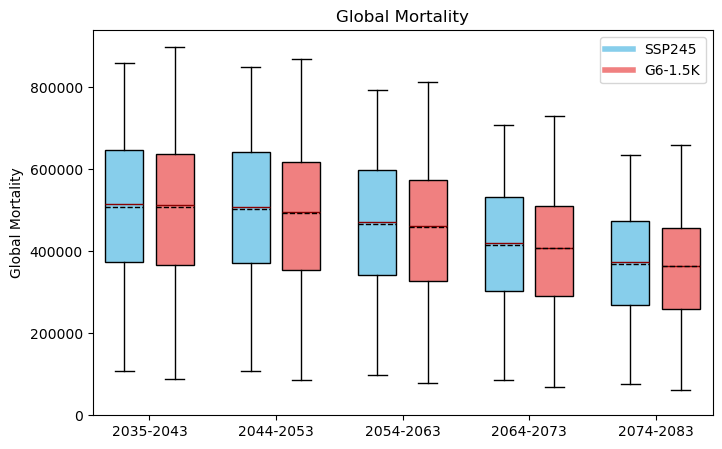

In [35]:
# === Plotting both scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]}_{scenario[1]}"

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

ds1 = load_global_mortality_ensemble_members(model, scenario[0], config1)
ds2 = load_global_mortality_ensemble_members(model, scenario[1], config2)

# In this case: ds1: G6-1.5K and ds2: SSP245 but we want SSP245 first
plot_2_box_plot(ds2.sel(year=ds1.year), ds1, model, scenario_name, SAVE_DIR)
